Import the necessary libraries to process string data in the language. 

In [2]:
import pandas as pd
import numpy as np
from numpy import array

import re
import nltk
from nltk.corpus import stopwords

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Activation, Dense, Dropout, Flatten
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

from keras.preprocessing.text import one_hot
from keras.layers import GlobalMaxPooling1D

from sklearn.model_selection import train_test_split

Using the IMDB movie rating dataset.

In [3]:
df = pd.read_csv('IMDB Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


View information about the dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df.shape

(50000, 2)

In [6]:
df.review[13]

"The cast played Shakespeare.<br /><br />Shakespeare lost.<br /><br />I appreciate that this is trying to bring Shakespeare to the masses, but why ruin something so good.<br /><br />Is it because 'The Scottish Play' is my favorite Shakespeare? I do not know. What I do know is that a certain Rev Bowdler (hence bowdlerization) tried to do something similar in the Victorian era.<br /><br />In other words, you cannot improve perfection.<br /><br />I have no more to write but as I have to write at least ten lines of text (and English composition was never my forte I will just have to keep going and say that this movie, as the saying goes, just does not cut it."

<AxesSubplot:xlabel='sentiment', ylabel='count'>

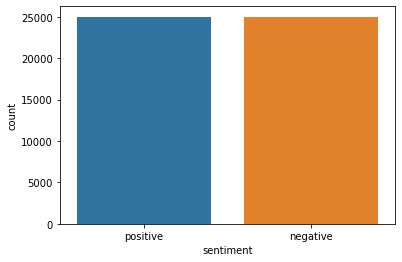

In [7]:
import seaborn as sns

sns.countplot(x='sentiment', data=df)

Process the data by removing extra tags, punctuation marks, numbers, single characters, and spaces.

In [8]:
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    return TAG_RE.sub('', text)

In [9]:
def preprocess_text(sen):
    # Removing html tags
    sentence = remove_tags(sen)

    # Remove punctuations and numbers
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)

    # Single character removal
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)

    # Removing multiple spaces
    sentence = re.sub(r'\s+', ' ', sentence)

    return sentence

In [10]:
X = []
sentences = list(df['review'])
for sen in sentences:
    X.append(preprocess_text(sen))

Change the positive and negative data labels to 1 and 0, respectively.

In [11]:
y = df['sentiment']

y = np.array(list(map(lambda x: 1 if x=="positive" else 0, y)))

Split training and test data into an 80:20 split.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

Convert string data into tokens.

In [13]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

In [14]:
vocab_size = len(tokenizer.word_index) + 1

maxlen = 100

X_train = pad_sequences(X_train, padding='post', maxlen=maxlen)
X_test = pad_sequences(X_test, padding='post', maxlen=maxlen)

Global Vectors for Word Representation

In [ ]:
from numpy import asarray

embeddings_dictionary = dict()
glove_file = open('glove.6B.100d.txt', encoding="utf8")

for line in glove_file:
    records = line.split()
    word = records[0]
    vector_dimensions = asarray(records[1:], dtype='float32')
    embeddings_dictionary [word] = vector_dimensions
glove_file.close()

In [ ]:
from numpy import zeros

embedding_matrix = zeros((vocab_size, 100))
for word, index in tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

In [17]:
print(embedding_matrix.shape)

(92547, 100)


In [18]:
print("x_train", X_train.shape)
print("y_train", y_train.shape)
print()
print("x_test", X_test.shape)
print("y_test", y_test.shape)

x_train (40000, 100)
y_train (40000,)

x_test (10000, 100)
y_test (10000,)


A simple model with an embedding layer and a flattening layer.

In [19]:
model = Sequential()
embedding_layer = Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)
model.add(embedding_layer)

model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

In [20]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 100)          9254700   
                                                                 
 flatten (Flatten)           (None, 10000)             0         
                                                                 


 dense (Dense)               (None, 1)                 10001     
                                                                 
Total params: 9,264,701
Trainable params: 10,001
Non-trainable params: 9,254,700
_________________________________________________________________
None


In [22]:
history = model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
250/250 [==============================] - 2s 7ms/step - loss: 0.6116 - acc: 0.6648 - val_loss: 0.5361 - val_acc: 0.7326
Epoch 2/6
250/250 [==============================] - 2s 7ms/step - loss: 0.4956 - acc: 0.7638 - val_loss: 0.5205 - val_acc: 0.7420
Epoch 3/6
250/250 [==============================] - 3s 11ms/step - loss: 0.4615 - acc: 0.7830 - val_loss: 0.5342 - val_acc: 0.7341
Epoch 4/6
250/250 [==============================] - 3s 11ms/step - loss: 0.4407 - acc: 0.7962 - val_loss: 0.5333 - val_acc: 0.7406
Epoch 5/6
250/250 [==============================] - 3s 11ms/step - loss: 0.4226 - acc: 0.8070 - val_loss: 0.5276 - val_acc: 0.7440
Epoch 6/6
250/250 [==============================] - 3s 11ms/step - loss: 0.4094 - acc: 0.8155 - val_loss: 0.5484 - val_acc: 0.7361


In [23]:
score = model.evaluate(X_test, y_test, verbose=1)

313/313 [==============================] - 1s 3ms/step - loss: 0.5488 - acc: 0.7391


In [24]:
print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.5488342046737671
Test Accuracy: 0.7390999794006348


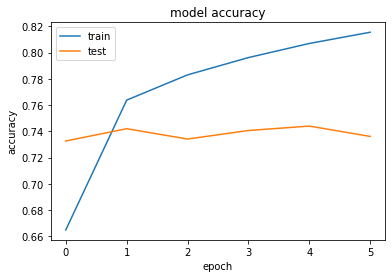

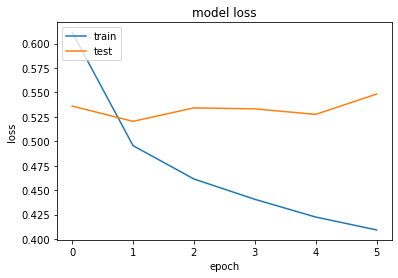

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

A simple model with an embedded layer and a convolutional layer.

In [26]:
from tensorflow.keras.layers import Conv1D

model = Sequential()

embedding_layer = Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)
model.add(embedding_layer)

model.add(Conv1D(128, 5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

In [27]:
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 100, 100)          9254700   
                                                                 
 conv1d (Conv1D)             (None, 96, 128)           64128     
                                                                 
 global_max_pooling1d (Globa  (None, 128)              0         
 lMaxPooling1D)                                                  
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 9,318,957
Trainable params: 64,257
Non-trainable params: 9,254,700
_________________________________________________________________
None


In [28]:
history = model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

score = model.evaluate(X_test, y_test, verbose=1)

Epoch 1/6
250/250 [==============================] - 12s 46ms/step - loss: 0.4983 - acc: 0.7538 - val_loss: 0.3976 - val_acc: 0.8180
Epoch 2/6
250/250 [==============================] - 11s 44ms/step - loss: 0.3676 - acc: 0.8382 - val_loss: 0.3720 - val_acc: 0.8292
Epoch 3/6
250/250 [==============================] - 11s 44ms/step - loss: 0.3151 - acc: 0.8696 - val_loss: 0.3586 - val_acc: 0.8396
Epoch 4/6
250/250 [==============================] - 11s 44ms/step - loss: 0.2779 - acc: 0.8877 - val_loss: 0.3427 - val_acc: 0.8457
Epoch 5/6
250/250 [==============================] - 11s 45ms/step - loss: 0.2399 - acc: 0.9074 - val_loss: 0.3429 - val_acc: 0.8457
Epoch 6/6
313/313 [==============================] - 3s 11ms/step - loss: 0.3664 - acc: 0.8382


In [29]:
print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.36637577414512634
Test Accuracy: 0.8381999731063843


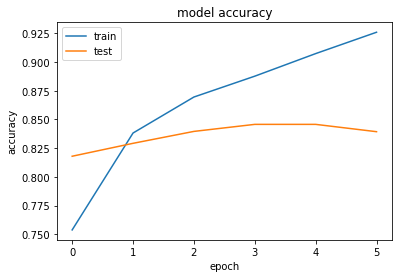

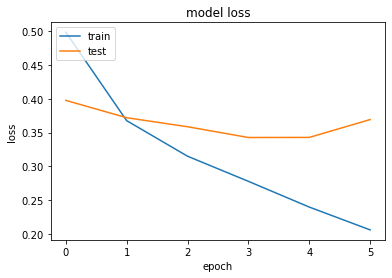

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

#Text Classification with Recurrent Neural Network (LSTM)

In [31]:
from tensorflow.keras.layers import LSTM

model = Sequential()
embedding_layer = Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)
model.add(embedding_layer)
model.add(LSTM(128))

model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

In [32]:
print(model.summary())

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 100, 100)          9254700   
                                                                 
 lstm (LSTM)                 (None, 128)               117248    
                                                                 
 dense_2 (Dense)             (None, 1)                 129       
                                                                 
Total params: 9,372,077
Trainable params: 117,377
Non-trainable params: 9,254,700
_________________________________________________________________
None


In [33]:
!pip show tensorflow

Name: tensorflow
Version: 2.12.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: c:\users\asus\anaconda3\lib\site-packages
Requires: tensorflow-intel
Required-by: 


In [34]:
history = model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

score = model.evaluate(X_test, y_test, verbose=1)

Epoch 1/6
250/250 [==============================] - 111s 438ms/step - loss: 0.5658 - acc: 0.6994 - val_loss: 0.4720 - val_acc: 0.7810
Epoch 2/6
250/250 [==============================] - 115s 462ms/step - loss: 0.4455 - acc: 0.7937 - val_loss: 0.4237 - val_acc: 0.7991
Epoch 3/6
250/250 [==============================] - 126s 503ms/step - loss: 0.3975 - acc: 0.8192 - val_loss: 0.3679 - val_acc: 0.8365
Epoch 4/6
250/250 [==============================] - 135s 541ms/step - loss: 0.3631 - acc: 0.8387 - val_loss: 0.3537 - val_acc: 0.8428
Epoch 5/6
250/250 [==============================] - 139s 554ms/step - loss: 0.3400 - acc: 0.8513 - val_loss: 0.3401 - val_acc: 0.8516
Epoch 6/6
313/313 [==============================] - 30s 95ms/step - loss: 0.3368 - acc: 0.8540


In [35]:
print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.33684536814689636
Test Accuracy: 0.8539999723434448


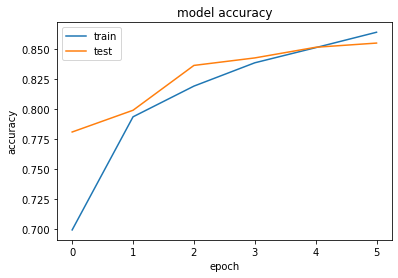

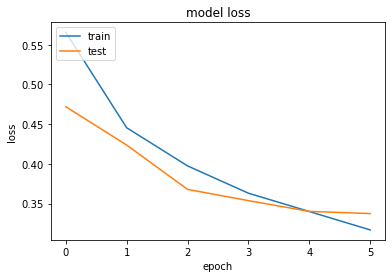

In [36]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

#Making Predictions on Single Instance

In [37]:
instance = X[57]
print(instance)

I laughed all the way through this rotten movie It so unbelievable woman leaves her husband after many years of marriage has breakdown in front of real estate office What happens The office manager comes outside and offers her job Hilarious Next thing you know the two women are going at it Yep they re lesbians Nothing rings true in this Lifetime for Women with nothing better to do movie Clunky dialogue like don want to spend the rest of my life feeling like had chance to be happy and didn take it doesn help There a wealthy distant mother who disapproves of her daughter new relationship sassy black maid unbelievable that in the year film gets made in which there a sassy black maid Hattie McDaniel must be turning in her grave The woman has husband who freaks out and wants custody of the snotty teenage kids Sheesh No cliche is left unturned 


In [38]:
instance = tokenizer.texts_to_sequences(instance)

flat_list = []
for sublist in instance:
    for item in sublist:
        flat_list.append(item)

flat_list = [flat_list]

instance = pad_sequences(flat_list, padding='post', maxlen=maxlen)

model.predict(instance)

1/1 [==============================] - 1s 667ms/step


array([[0.44391975]], dtype=float32)

#CNN-LSTM

In [39]:
CNN_LSTM = Sequential()
embedding_layer = Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)
CNN_LSTM.add(embedding_layer)
CNN_LSTM.add(Conv1D(128, 5, activation='relu'))
CNN_LSTM.add(LSTM(128))

CNN_LSTM.add(Dense(1, activation='sigmoid'))
CNN_LSTM.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

In [40]:
CNN_LSTM.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 100, 100)          9254700   
                                                                 
 conv1d_1 (Conv1D)           (None, 96, 128)           64128     
                                                                 
 lstm_1 (LSTM)               (None, 128)               131584    
                                                                 
 dense_3 (Dense)             (None, 1)                 129       
                                                                 
Total params: 9,450,541
Trainable params: 195,841
Non-trainable params: 9,254,700
_________________________________________________________________


In [41]:
history = CNN_LSTM.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

score = CNN_LSTM.evaluate(X_test, y_test, verbose=1)

Epoch 1/6
250/250 [==============================] - 135s 532ms/step - loss: 0.5376 - acc: 0.7188 - val_loss: 0.4243 - val_acc: 0.8073
Epoch 2/6
250/250 [==============================] - 143s 571ms/step - loss: 0.4059 - acc: 0.8182 - val_loss: 0.4041 - val_acc: 0.8256
Epoch 3/6
250/250 [==============================] - 156s 624ms/step - loss: 0.3625 - acc: 0.8422 - val_loss: 0.3557 - val_acc: 0.8430
Epoch 4/6
250/250 [==============================] - 166s 666ms/step - loss: 0.3219 - acc: 0.8628 - val_loss: 0.3678 - val_acc: 0.8395
Epoch 5/6
250/250 [==============================] - 151s 605ms/step - loss: 0.2844 - acc: 0.8830 - val_loss: 0.3697 - val_acc: 0.8355
Epoch 6/6
313/313 [==============================] - 31s 98ms/step - loss: 0.4343 - acc: 0.8137


In [42]:
print("Test Score (CNN_LSTM):", score[0])
print("Test Accuracy (CNN_LSTM):", score[1])

Test Score (CNN_LSTM): 0.4343004524707794
Test Accuracy (CNN_LSTM): 0.8137000203132629


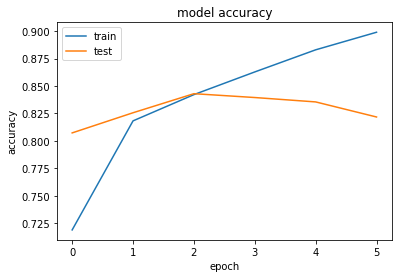

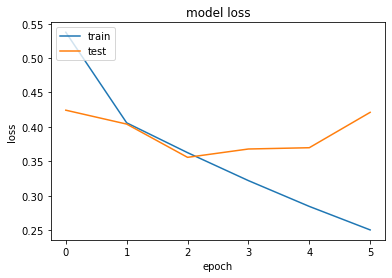

In [43]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

#BLSTM

In [44]:
from tensorflow.keras.layers import Bidirectional

BLSTM = Sequential()
embedding_layer = Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)
BLSTM.add(embedding_layer)
BLSTM.add(Bidirectional(LSTM(128)))

BLSTM.add(Dense(1, activation='sigmoid'))
BLSTM.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

In [45]:
BLSTM.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_4 (Embedding)     (None, 100, 100)          9254700   
                                                                 
 bidirectional (Bidirectiona  (None, 256)              234496    
 l)                                                              
                                                                 
 dense_4 (Dense)             (None, 1)                 257       
                                                                 
Total params: 9,489,453
Trainable params: 234,753
Non-trainable params: 9,254,700
_________________________________________________________________


In [46]:
history = BLSTM.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

score = BLSTM.evaluate(X_test, y_test, verbose=1)

Epoch 1/6
250/250 [==============================] - 185s 720ms/step - loss: 0.5290 - acc: 0.7266 - val_loss: 0.4475 - val_acc: 0.7991
Epoch 2/6
250/250 [==============================] - 229s 919ms/step - loss: 0.4352 - acc: 0.7968 - val_loss: 0.4440 - val_acc: 0.7834
Epoch 3/6
250/250 [==============================] - 255s 1s/step - loss: 0.3869 - acc: 0.8269 - val_loss: 0.3675 - val_acc: 0.8331
Epoch 4/6
250/250 [==============================] - 195s 777ms/step - loss: 0.3596 - acc: 0.8392 - val_loss: 0.3518 - val_acc: 0.8460
Epoch 5/6
250/250 [==============================] - 160s 640ms/step - loss: 0.3382 - acc: 0.8518 - val_loss: 0.3613 - val_acc: 0.8369
Epoch 6/6
313/313 [==============================] - 15s 47ms/step - loss: 0.3410 - acc: 0.8497


In [47]:
print("Test Score (CNN_LSTM):", score[0])
print("Test Accuracy (CNN_LSTM):", score[1])

Test Score (CNN_LSTM): 0.3410046100616455
Test Accuracy (CNN_LSTM): 0.8496999740600586


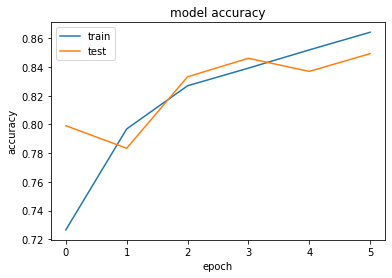

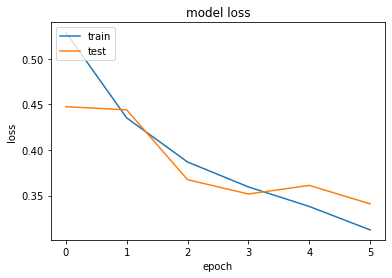

In [48]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()